<a href="https://colab.research.google.com/github/kyliequinney/MachineLearning4375/blob/main/4375Assignment2/4375Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training MSE:  4.207958887738523
Training MAE:  1.4634210759109516
Training Accuracy: 0.5957408039157512
Test MSE:  4.17952291821853
Test MAE:  1.4410031468359845
Test Accuracy:  0.5956936961586979


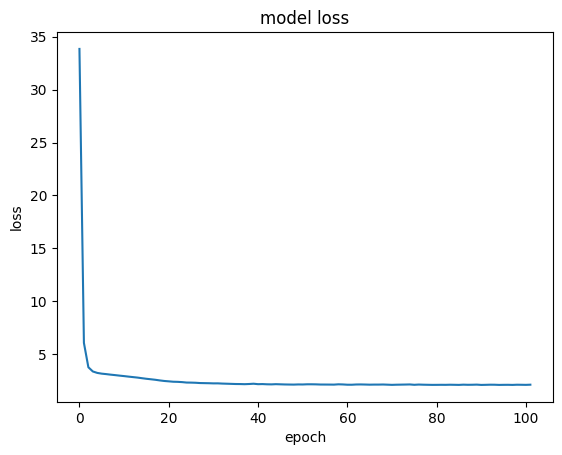

[33.8450379963838, 6.064867955875063, 3.761218814602605, 3.363222866037811, 3.2265554833175463, 3.156698765177148, 3.113238180351489, 3.06226663497643, 3.017828786552932, 2.970085623412503, 2.925570304503449, 2.876614266959522, 2.8307874978077394, 2.7855160291539534, 2.7271349552485806, 2.6722160899132774, 2.626230535961961, 2.5776509607177593, 2.516890744178799, 2.465261052069573, 2.4308372038662354, 2.39403052516118, 2.382504484904202, 2.357213638010203, 2.3159354907849328, 2.310270372256078, 2.2964223516686286, 2.269346672989428, 2.2608681424109975, 2.2530353386424005, 2.2381517998327825, 2.239977046536277, 2.2186274702636006, 2.2057557029824713, 2.191878278904001, 2.177904902847139, 2.173786045100115, 2.162304159986463, 2.1788965249713512, 2.204970832627517, 2.163249602066669, 2.1720336416365655, 2.151933081528319, 2.143837660899161, 2.163150820355738, 2.1486641468304835, 2.1357638114366035, 2.1289697220112034, 2.1232155493396667, 2.1382189886208143, 2.1341337679901415, 2.151254575

In [ ]:
#####################################################################################################################
#   Assignment 2: Neural Network Analysis
#   This is a starter code in Python 3.6 for a neural network.
#   You need to have numpy and pandas installed before running this code.
#   You need to complete all TODO marked sections
#   You are free to modify this code in any way you want, but need to mention it
#       in the README file.
#
#####################################################################################################################


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


class NeuralNet:
    def __init__(self, dataFile, header=True):
        self.raw_input = pd.read_csv(dataFile)

    def head(self):
        print(self.raw_input.head())

    # TODO: Write code for pre-processing the dataset, which would include
    # standardization, normalization,
    # categorical to numerical, etc
    def preprocess(self):
        df = pd.DataFrame(self.raw_input)
        #change sex column to number labels
        df['Sex'] = self.raw_input['Sex'].map({'M': 1, 'F': 2, 'I': 3})
        df.drop_duplicates(inplace=True)
        y = df['Rings']
        X = df.drop('Rings', axis=1)
        # standardize and normalize the attributes
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        df = pd.DataFrame(X_scaled, columns=X.columns)
        self.processed_data = df
        self.y = y

        return 0

    def describe(self):
        print(self.processed_data.describe())

    # TODO: Train and evaluate models for all combinations of parameters
    # specified in the init method. We would like to obtain following outputs:
    #   1. Training Accuracy and Error (Loss) for every model
    #   2. Test Accuracy and Error (Loss) for every model
    #   3. History Curve (Plot of Accuracy against training steps) for all
    #       the models in a single plot. The plot should be color coded i.e.
    #       different color for each model

    def train_evaluate(self):
        ncols = len(self.processed_data.columns)
        nrows = len(self.processed_data.index)
        X = self.processed_data.iloc[:, 0:(ncols - 1)]
        #y = self.processed_data.iloc[:, (ncols-1)]
        y = self.y
        X_train, X_test, y_train, y_test = train_test_split(
            X, y)

        # Below are the hyperparameters that you need to use for model evaluation
        # You can assume any fixed number of neurons for each hidden layer.

        activations = ['logistic', 'tanh', 'relu']
        learning_rate = [0.01, 0.1]
        max_iterations = [100, 200] # also known as epochs
        num_hidden_layers = [2, 3]

        # Create the neural network and be sure to keep track of the performance
        # metrics
        from sklearn.neural_network import MLPRegressor
        mlp = MLPRegressor(random_state=0, solver='adam', max_iter=400, activation='tanh',
                           hidden_layer_sizes=(100,100,100), learning_rate='adaptive')
        mlp.fit(X_train,y_train)
        predictions_train = mlp.predict(X_train)
        predictions_test = mlp.predict(X_test)
        from sklearn.metrics import mean_squared_error
        from sklearn.metrics import mean_absolute_error

        #output evaluation metrics
        print('Training MSE: ', mean_squared_error(y_train,predictions_train))
        print('Training MAE: ', mean_absolute_error(y_train,predictions_train))
        print('Training Accuracy:', mlp.score(X_train, y_train))

        print('Test MSE: ', mean_squared_error(y_test,predictions_test))
        print('Test MAE: ', mean_absolute_error(y_test,predictions_test))
        print('Test Accuracy: ', mlp.score(X_test,y_test))

        #plot loss v epoch
        mlp.loss_curve_
        plt.plot(mlp.loss_curve_)
        plt.title('model loss')
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.show()
        print(mlp.loss_curve_)
        return 0

if __name__ == "__main__":
    neural_network = NeuralNet("https://raw.githubusercontent.com/kyliequinney/WineQualityData/refs/heads/main/abalone.csv") # put in path to your file
    neural_network.preprocess()
    neural_network.train_evaluate()


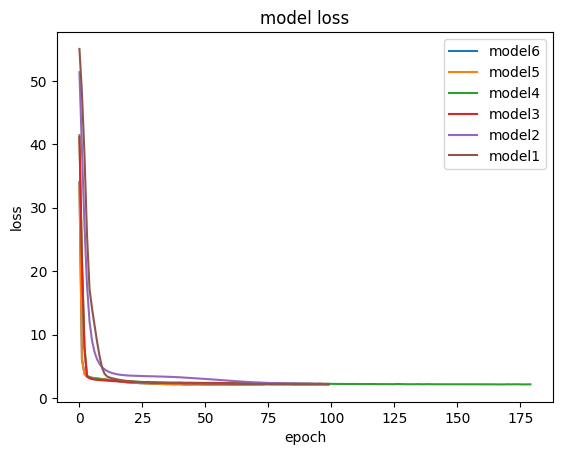

In [ ]:
# Plot the model history for each model in a single plot

# model history is a plot of loss vs number of epochs

# you may want to create a large sized plot to show multiple lines
# in a same figure.
model6=[34.030605765779704, 6.077684011466348, 3.830866329086284, 3.398581990105366, 3.252025320459787, 3.1829064951557107, 3.129747430754924, 3.076121576332598, 3.026623458598862, 2.975548554012066, 2.9336052406540643, 2.880918214798807, 2.8320815430058546, 2.7837019530889067, 2.7268676290040896, 2.6682960755183958, 2.611670409561512, 2.554476453829798, 2.5084912396992207, 2.4567468991104118, 2.430626119095264, 2.385139976202867, 2.375213936060323, 2.345980338409219, 2.3199555859572083, 2.325250090800076, 2.301767581447247, 2.28312280920754, 2.2711277028472394, 2.2392832196804577, 2.236361546764226, 2.2253440151712596, 2.2020760369249794, 2.199733218701129, 2.181918693089613, 2.154691554659988, 2.1627759857870275, 2.142201948544504, 2.139946731433129, 2.1652237370091503, 2.1592337277716274, 2.1383707492219415, 2.118101717065323, 2.118433939793725, 2.121762171898204, 2.1326283487445674, 2.134537331750206, 2.146496665730823, 2.133200227082115, 2.117714695243623, 2.11665858465434, 2.1041777669036987, 2.111462597258404, 2.101048961541364, 2.1030328737474084, 2.1381459371683196, 2.102625616130844, 2.120675146019647, 2.112585806803854, 2.0978743786698075, 2.08440337681959, 2.088689650402389, 2.08231932131107, 2.097151451653914, 2.0856892167258616, 2.0919737460099737, 2.1058146620796947, 2.1142798869019956, 2.105369858475321, 2.0902134684750213, 2.0947945758528874, 2.1102641059465728, 2.1017440247489168, 2.1074846611117106]
model5=[33.75767213422826, 6.023565506143951, 3.768370521164809, 3.3500197545405768, 3.2294753663814277, 3.158333350147282, 3.115599449743207, 3.056159909994267, 3.0103401421763962, 2.9673171219729153, 2.91450357265124, 2.871644630308486, 2.818817278944282, 2.771622606901555, 2.716215494728441, 2.65787066278362, 2.598171943539329, 2.5491090724342014, 2.501528929374934, 2.453630092352184, 2.4065365199061515, 2.381044094800352, 2.359439479168882, 2.361154393815611, 2.338872095042211, 2.3045619508861344, 2.2880234618471116, 2.281191332036918, 2.244960047674836, 2.2494871863900783, 2.2376378844068125, 2.239496286895173, 2.215497110049442, 2.193899731411114, 2.1820980310883864, 2.188104148659964, 2.1967566533895577, 2.191952040811327, 2.180315618068785, 2.1578925139373437, 2.151530508421265, 2.1327219058892037, 2.1293328817485806, 2.1235589503563697, 2.129362496202916, 2.1262421109842315, 2.126171209658337, 2.114751146763392, 2.1201281427935066, 2.105827237761792, 2.105677168687428, 2.1050999623613493, 2.087020250571213, 2.097675613909708, 2.0904680442306938, 2.092032914281199, 2.1119140257774984, 2.1120082522775463, 2.0862308540968377, 2.092736343389862, 2.075233413387608, 2.0812264120653916, 2.1028698562107406, 2.1202242363793604, 2.0887027388956607, 2.104034621105013, 2.072454803684268, 2.0763792709032014, 2.0873753111156343, 2.0753471833350217, 2.075498626527756, 2.1058599169108243, 2.0830359891471413, 2.107611626844523, 2.0889700983990886, 2.0994421869909154, 2.063941993786352, 2.065807571797509, 2.0722441768993813, 2.0659516073224204, 2.0699399069495965, 2.0589748128814964, 2.0816100546561267, 2.0936998262449094, 2.073253434177017, 2.0606799485791694, 2.0514667725072995, 2.0682311920946295, 2.0492745059519684, 2.058237854631898, 2.0683630136768665, 2.0616634588532428, 2.057521013877123, 2.0598072571536092, 2.0569628378504867, 2.0621052066931402, 2.0701879915124097, 2.0682076794987885, 2.0608359287502678, 2.075636615616044]
model4=[41.43869047656672, 21.663536072336516, 8.101109759738927, 3.5428023850704884, 3.258312432622438, 3.1233216765556535, 3.0386321600398603, 2.987768341786747, 2.9495581910518953, 2.9102759899651165, 2.8851768160139994, 2.841488297338282, 2.811892287031089, 2.7826099211498536, 2.7542541536651726, 2.724273766779412, 2.705676581757071, 2.6789701064261546, 2.6570303124768206, 2.630013700253847, 2.6049353102705504, 2.5823214153447296, 2.5705131597915267, 2.5607005855642324, 2.53775360529737, 2.5201789228886566, 2.4981708789785935, 2.52346677053969, 2.488549391251641, 2.4667343487450415, 2.4593026593273306, 2.4580534872404476, 2.4469582334313857, 2.4423598004141254, 2.4395358478966562, 2.4337713159365966, 2.429711367920473, 2.4150612567175624, 2.4124554324060123, 2.4221877777867715, 2.40711630511951, 2.4084115942014113, 2.3990278369010385, 2.3923154866362313, 2.403976506227135, 2.385008694069198, 2.3812957309867127, 2.3789059926565606, 2.3812907743313727, 2.3787620364975366, 2.3727612287072057, 2.3669379609603096, 2.373301492823801, 2.3736071235668277, 2.380136620801942, 2.354597946907735, 2.3578905747560284, 2.352007788853934, 2.348367757064319, 2.3484106883584275, 2.3444803863108623, 2.3420472343197614, 2.3365831070771534, 2.32923227726366, 2.3246682013885747, 2.3296837892054207, 2.3179171151449536, 2.3168841894203314, 2.3180045506336415, 2.3297545661461196, 2.314761374614331, 2.311340335558316, 2.30300431591904, 2.3039261840041516, 2.30066980582461, 2.289656497043983, 2.2869483176824907, 2.289362700226943, 2.2744233035295043, 2.2773655578402523, 2.288073960122076, 2.2766908563291657, 2.267796832581857, 2.2752322801734284, 2.2670961583353804, 2.2612600668258684, 2.251679032017656, 2.2595979675005866, 2.2461621946682446, 2.2552541317245853, 2.249189946650874, 2.2532390529846253, 2.2343071052372703, 2.2382208412548112, 2.2278310845107274, 2.221020396173222, 2.22566587247579, 2.2240340635997344, 2.2114723880348266, 2.223953522285077, 2.2190575909255283, 2.2041066147564807, 2.2027269234862312, 2.204915043702273, 2.2114518115011097, 2.219486765900303, 2.1977294591157808, 2.1892764843419488, 2.193475148031063, 2.2037191620179737, 2.1939154853561216, 2.184021509335357, 2.1872484939057424, 2.1832682946442326, 2.188240718632817, 2.1957578859440683, 2.2005094322261725, 2.1961224183217647, 2.1726490461322046, 2.178800176879912, 2.180294770945806, 2.1790762189996866, 2.176536301422171, 2.17617406340404, 2.167990838490936, 2.166459456617747, 2.202018529228216, 2.1850089124345633, 2.1662338400615035, 2.16228333287596, 2.1573899309485514, 2.1611300904218798, 2.1567867163369137, 2.16103401819879, 2.155005176053166, 2.1752083076011264, 2.14883345445776, 2.1643055092648082, 2.1741800489596086, 2.16158636154265, 2.1518289875929297, 2.152901032495847, 2.1530323271591536, 2.148070056571162, 2.1503300673492256, 2.1534396868405783, 2.1469260047863385, 2.158844333004412, 2.143163946062502, 2.15653058238182, 2.143914224057533, 2.1458655259020474, 2.146625583739998, 2.158505979745925, 2.153560841001287, 2.147099420161318, 2.137885564415448, 2.1515369697024314, 2.1431283865976414, 2.147851167676807, 2.1417521689645955, 2.1462543810725307, 2.14158161971042, 2.1465806815962574, 2.1458423982257164, 2.1311902737965864, 2.131288698480093, 2.1317286197296603, 2.1258284553100166, 2.135807953306843, 2.1576880220356824, 2.138685449951627, 2.149762021083205, 2.1517412711508146, 2.154810227975626, 2.137012289868202, 2.1263106148874718, 2.130423162676917, 2.139060828808038, 2.139760647302285]
model3=[41.15498451577743, 21.228286952369274, 7.678585794832413, 3.365064999506184, 3.0900334585662352, 2.975811232442036, 2.8933845119555612, 2.8511900283508402, 2.8118392049385403, 2.7801980610298638, 2.750980306900563, 2.721955603919615, 2.6881900309672133, 2.6653932592738396, 2.6439342699587485, 2.617934851074092, 2.5969737167805005, 2.571696430760425, 2.5538025778856026, 2.5318849090091335, 2.50477634846675, 2.489459786028053, 2.475291244167824, 2.4605832344641616, 2.446060959110271, 2.4386926237442643, 2.450540701350325, 2.4296231284917376, 2.406330881325062, 2.3913750303472976, 2.4122002000347, 2.38181107072919, 2.373924417271216, 2.371884763155338, 2.3762052872344284, 2.362797499698575, 2.3572537138152856, 2.355755438039221, 2.3575529101082267, 2.3530454564625196, 2.3740404449423136, 2.3358845568326134, 2.3351320667651203, 2.3492231027622674, 2.3405476592993226, 2.3237641463757206, 2.3225399996387885, 2.3394640456612796, 2.3250306089775665, 2.3219786943400647, 2.312816925037262, 2.318630710494881, 2.311340558510925, 2.318474299398697, 2.3053957726507956, 2.327660036955615, 2.3492399462020814, 2.3162871513873355, 2.2988683733272754, 2.2986293802205084, 2.2908993543217955, 2.2912010620217114, 2.284227715070397, 2.2908655622923852, 2.3062456628342294, 2.2835690680765968, 2.2937354425839556, 2.2781437269669857, 2.278448633020765, 2.2738514824140172, 2.275757311624022, 2.2744206805086375, 2.276838079754859, 2.256219579678841, 2.264202102548898, 2.2729943208577734, 2.2626950042500447, 2.2606118715487185, 2.2509149519465628, 2.2474099581378666, 2.244221710121098, 2.247405024851627, 2.249973159677821, 2.243792237122094, 2.233276942428094, 2.237454425679608, 2.2396256144583604, 2.2368266822596605, 2.2288654669737302, 2.226114777372989, 2.2221633795625237, 2.222380105433023, 2.21371061616126, 2.2152841864451345, 2.2108988422604514, 2.239691493185474, 2.227922018559309, 2.204175600917604, 2.2030225123339258, 2.1969594374568615]
model2=[51.37909177526624, 39.09831548269141, 27.164308100540325, 17.76761530898594, 12.082503854350191, 9.010842006741283, 7.224242061827859, 6.1010779606957, 5.3556601057735795, 4.84372028766153, 4.497546861969779, 4.241860049977767, 4.058551145490584, 3.915418364995543, 3.8129071062891713, 3.7245755338092423, 3.66380309888055, 3.615490076509338, 3.5775285631201132, 3.5468820020480814, 3.524042706460796, 3.5050182328344026, 3.4897183451691043, 3.478814151503597, 3.4618634689699115, 3.447494125488572, 3.436911013779876, 3.4271435680497278, 3.417557690228864, 3.4091565982010397, 3.3963258950558233, 3.384466500721745, 3.374852061493747, 3.3633454620776866, 3.350293035701163, 3.3359754578777467, 3.3214648133687605, 3.3061996133238836, 3.289259833902584, 3.2683961853810644, 3.245006360227017, 3.22201172711978, 3.196874256048155, 3.1732084229590116, 3.146342977957288, 3.11958506692251, 3.0939290106578414, 3.068691401273548, 3.044546262168194, 3.0183682939395244, 2.9930982043880374, 2.96460973806041, 2.9363017569837506, 2.9083544141920985, 2.881693354753862, 2.850943150921014, 2.821683478946714, 2.7891286813750247, 2.7614585414983277, 2.7288106029673442, 2.6976175572153265, 2.6903193518492836, 2.640513482634568, 2.6151724610555385, 2.5863655383109405, 2.5623674490318398, 2.5398191902447325, 2.5145250625458497, 2.486471509938491, 2.4637543327485356, 2.4477188197629225, 2.443477913781271, 2.42154508884178, 2.396192664239476, 2.3782678868376843, 2.372009245605084, 2.3479857245164073, 2.34186238350518, 2.333673542485639, 2.330733182115046, 2.315287827853838, 2.3047498462610743, 2.2858220935006166, 2.2820459624936014, 2.2785612315184287, 2.27004448277372, 2.2597229055841987, 2.2450268397239594, 2.250878722798135, 2.25024346657135, 2.2363655761040264, 2.2521590466339054, 2.2353030019453817, 2.2182780423306596, 2.2143136835308335, 2.2074109873963814, 2.2070127678531484, 2.2007322872370296, 2.1989367234127517, 2.203689900094987]
model1=[55.049565994678474, 47.999778554342846, 38.28710420754441, 25.722363536025924, 17.17093627037851, 14.092670721940241, 11.44774787758244, 8.87546198869633, 6.5573102748542915, 4.743002820994774, 3.7891357813687954, 3.3856256652142442, 3.212429085185706, 3.1039393670579907, 3.0109063537543195, 2.924045927018769, 2.8450339349598224, 2.7742130183010114, 2.7158386124974454, 2.666869806567073, 2.6342370401463606, 2.59403837978283, 2.5505092462490553, 2.5291322588145984, 2.4962652133248695, 2.473898502807819, 2.4598183904923796, 2.4450575539438675, 2.421420217793286, 2.4092233347823093, 2.3961682013837673, 2.377325254420218, 2.364069812772976, 2.362067596838186, 2.3477589308405933, 2.3482194689545737, 2.3322147065984207, 2.3286864271504037, 2.319864998150016, 2.3117009214351305, 2.318087044486927, 2.297188890851897, 2.308338821768071, 2.2832859017075378, 2.288249635413715, 2.281234220898186, 2.2904223065144858, 2.273057902367134, 2.2733157474867176, 2.2641797356891744, 2.2604660217538064, 2.260933704604052, 2.2587372240045953, 2.254729758736924, 2.2489608756010973, 2.2419225565051484, 2.242395469737407, 2.2385672989049565, 2.235912731722956, 2.2369002214282263, 2.2422951310242722, 2.2337057196889885, 2.2377832330279888, 2.2211747131169184, 2.2214825661126594, 2.2270800013288685, 2.2164377351855498, 2.21729689570193, 2.221202233677968, 2.2072751388141167, 2.2090829017957447, 2.2140451296005486, 2.2103306575258674, 2.2147816155342057, 2.2160626596074944, 2.2001709785197536, 2.1959193989287193, 2.197866548261718, 2.1907589857045773, 2.1927725152060242, 2.1928703433968106, 2.194089968510983, 2.181141356367977, 2.1782800221166876, 2.1717091115177634, 2.1758945534602243, 2.17387604913883, 2.181243387890419, 2.170845431373037, 2.168985718076169, 2.178662728022574, 2.1664701096005934, 2.1811743592029713, 2.1712501056826947, 2.1641154165509913, 2.1877297926778287, 2.1670181891346467, 2.1590977206967903, 2.156442076837507, 2.1621981841284903]

plt.plot(model6, label='model6')
plt.plot(model5, label='model5')
plt.plot(model4, label='model4')
plt.plot(model3, label='model3')
plt.plot(model2, label='model2')
plt.plot(model1, label='model1')
plt.legend()
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()